In [1]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt

# carregar áudio
fs, signal = wavfile.read("drone2.wav")

# converter para float (importante!)
signal = signal.astype(float)

# velocidade do som
c = 343  

# posições dos microfones (5 cm entre cada)
mic_positions = np.array([
    [0.0, 0.0],          # Mic1
    [0.05, 0.0],         # Mic2
    [0.025, 0.0433]      # Mic3
])

# direção da fonte (graus)
theta_deg = 115
theta = np.deg2rad(theta_deg)

# vetor unitário da direção
direction = np.array([np.cos(theta), np.sin(theta)])

# calcular atrasos (em segundos)
delays = mic_positions @ direction / c

# normalizar (opcional, para começar no mínimo = 0)
delays = delays - np.min(delays)

# converter para samples
delays_samples = delays * fs

# função para aplicar atraso (simples)
def apply_delay(signal, delay_samples):
    n = int(np.round(delay_samples))
    return np.concatenate((np.zeros(n), signal))[:len(signal)]

# gerar sinais dos microfones
signals = []
for d in delays_samples:
    signals.append(apply_delay(signal, d))

# normalizar
signals = [sig / np.max(np.abs(sig)) for sig in signals]
signals = [sig * 32767 for sig in signals]

# guardar ficheiros
for i, sig in enumerate(signals):
    wavfile.write(f"mic_{i+1}.wav", fs, sig.astype(np.int16))

print("Sinais gerados com sucesso")


# Função para simular (para ser mais pratico)
def simulate(theta_deg, signal, fs, mic_positions, c=343):
    
    theta = np.deg2rad(theta_deg)

    direction = np.array([np.cos(theta), np.sin(theta)])

    # atrasos
    delays = mic_positions @ direction / c
    delays = delays - np.min(delays)
    delays_samples = delays * fs

    def apply_delay(sig, delay_samples):
        n = int(np.round(delay_samples))
        return np.concatenate((np.zeros(n), sig))[:len(sig)]

    signals = []
    for d in delays_samples:
        signals.append(apply_delay(signal, d))

    # normalizar
    signals = [s / np.max(np.abs(s)) for s in signals]
    signals = [s * 32767 for s in signals]

    return signals

Sinais gerados com sucesso


Atrasos por microfone:
Mic 1: 0.99 samples | 0.062 ms
Mic 2: 0.00 samples | 0.000 ms
Mic 3: 2.32 samples | 0.145 ms


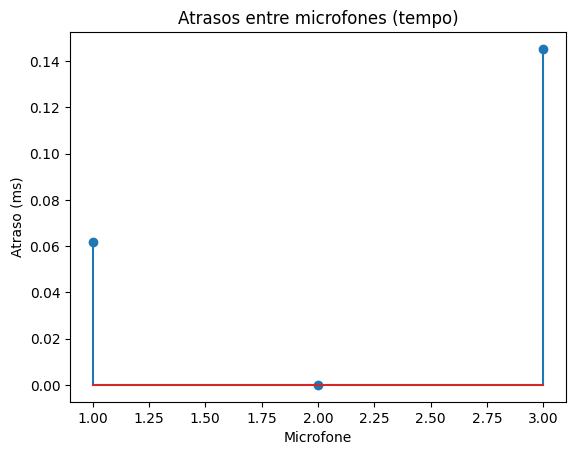

In [2]:
# imprimir valores
print("Atrasos por microfone:")
for i, (d_s, d_t) in enumerate(zip(delays_samples, delays)):
    print(f"Mic {i+1}: {d_s:.2f} samples | {d_t*1000:.3f} ms")

# gráfico 1: atrasos em milissegundos
plt.figure()
plt.stem(range(1, len(delays)+1), delays * 1000)
plt.xlabel("Microfone")
plt.ylabel("Atraso (ms)")
plt.title("Atrasos entre microfones (tempo)")
plt.show()

## Para validação:

In [3]:
# velocidade do som
c = 343  

# posições dos microfones
mic_positions = np.array([
    [0.0, 0.0],          
    [0.05, 0.0],         
    [0.025, 0.0433]      
])

fs = 44100

def test_angle(theta_deg):
    theta = np.deg2rad(theta_deg)
    direction = -np.array([np.cos(theta), np.sin(theta)])
    
    delays = mic_positions @ direction / c
    delays = delays - np.min(delays)
    delays_samples = delays * fs

    print(f"\n=== Ângulo: {theta_deg}º ===")
    for i, d in enumerate(delays_samples):
        print(f"Mic {i+1}: {d:.2f} samples")

# testes
test_angle(0)
test_angle(90)
test_angle(30)


=== Ângulo: 0º ===
Mic 1: 6.43 samples
Mic 2: 0.00 samples
Mic 3: 3.21 samples

=== Ângulo: 90º ===
Mic 1: 5.57 samples
Mic 2: 5.57 samples
Mic 3: 0.00 samples

=== Ângulo: 30º ===
Mic 1: 5.57 samples
Mic 2: 0.00 samples
Mic 3: 0.00 samples


## Breakdown dos resultados:

Ângulo 0º : o som vem da direita, logo, o microfone 1 vai ser o primeiro a receber
Ângulo 90º : o som vem de cima (frente) o microfone que recebe primeiro é o 3
Ângulo 30ª : como o triangulo é equilatero 30º fica exatamente com a mesma distância do microfone da frente e do lado direito, logo, recebem os dois exatamente ao mesmo tempo o som. 

Obs: Este fenómeno quando os microfones estão têm o mesmo atraso pode causar ambiguidade em alguns algoritmos como o GCC-PHAT

## Próximo passo, calcular o ângulo do som, usando Correlação e GCC-PHAT usando 2 microphones

In [4]:
# Correlação

def cross_correlation_tdoa(x, y):
    corr = np.correlate(x, y, mode='full')
    delay = np.argmax(corr) - (len(x) - 1)
    return delay

In [5]:
# GCC-PHAT

def gcc_phat(x, y, fs):
    N = len(x) + len(y)
    
    X = np.fft.fft(x, n=N)
    Y = np.fft.fft(y, n=N)
    
    R = X * np.conj(Y)
    R /= (np.abs(R) + 1e-8)
    
    corr = np.fft.ifft(R)
    corr = np.real(corr)
    
    max_shift = len(corr) // 2
    corr = np.concatenate((corr[-max_shift:], corr[:max_shift+1]))
    
    delay = np.argmax(corr) - max_shift
    
    return delay

In [6]:
# Converter atraso para angulo, usando apenas 2 microfones

def tdoa_to_angle(delay_samples, fs, d):
    dt = delay_samples / fs
    value = (c * dt) / d
    
    # evitar erro matemático
    value = np.clip(value, -1, 1)
    
    theta = np.arcsin(value)
    return np.rad2deg(theta)

In [7]:
# Teste simples, usar apenas um par 

# escolher par
x = signals[0]
y = signals[1]

# delays
delay_corr = cross_correlation_tdoa(x, y)
delay_gcc = gcc_phat(x, y, fs)

print("\n=== TDOA ===")
print("Cross-corr:", delay_corr)
print("GCC-PHAT:", delay_gcc)

# converter para ângulo
d = 0.05  # distância entre Mic1 e Mic2

angle_corr = tdoa_to_angle(delay_corr, fs, d)
angle_gcc = tdoa_to_angle(delay_gcc, fs, d)

print("\n=== Ângulos estimados ===")
print("Real:", theta_deg)
print("Cross-corr:", angle_corr)
print("GCC-PHAT:", angle_gcc)


=== TDOA ===
Cross-corr: 1
GCC-PHAT: 1

=== Ângulos estimados ===
Real: 115
Cross-corr: 8.949018065329238
GCC-PHAT: 8.949018065329238


In [8]:
def estimate_angle_3mics(signals, fs):
    pairs = [(0,1), (0,2), (1,2)]
    angles = []
    
    for i, j in pairs:
        delay = gcc_phat(signals[i], signals[j], fs)
        d = np.linalg.norm(mic_positions[i] - mic_positions[j])
        
        angle = tdoa_to_angle(delay, fs, d)
        angles.append(angle)
    
    return angles

angles = estimate_angle_3mics(signals, fs)

print("\nÂngulos por par:")
for a in angles:
    print(a)


Ângulos por par:
8.949018065329238
-8.949216567076368
-18.12661661007281


## Agora usando os 3 microfones

### Cada par de microfones dá um TDOA, que corresponde a uma linha possível de direções, com 3 pares, vamos intercetar para obter a direção real

In [9]:
# Calcular TDOA reais
def get_tdoas(signals, fs):
    pairs = [(0,1), (0,2), (1,2)]
    tdoas = []
    
    for i, j in pairs:
        delay = gcc_phat(signals[i], signals[j], fs)
        tdoas.append(delay)
    
    return np.array(tdoas)


# Função de erro
def compute_error(theta_deg, mic_positions, tdoas_measured, fs):
    theta = np.deg2rad(theta_deg)
    direction = np.array([np.cos(theta), np.sin(theta)])  # sem sinal negativo
    
    # atrasos teóricos (SEM normalizar)
    delays = mic_positions @ direction / c
    delays_samples = delays * fs

    pairs = [(0,1), (0,2), (1,2)]
    
    tdoas_theoretical = []
    for i, j in pairs:
        tdoas_theoretical.append(delays_samples[i] - delays_samples[j])
    
    tdoas_theoretical = np.array(tdoas_theoretical)
    
    error = np.sum((tdoas_measured - tdoas_theoretical)**2)
    
    return error

# Procurar o melhor ângulo
def estimate_angle(signals, fs, mic_positions):
    tdoas_measured = get_tdoas(signals, fs)
    
    angles = np.linspace(0, 180, 181)
    errors = []
    
    for theta in angles:
        err = compute_error(theta, mic_positions, tdoas_measured, fs)
        errors.append(err)
    
    best_angle = angles[np.argmin(errors)]
    
    return best_angle, angles, errors


=== RESULTADO FINAL ===
Ângulo real: 115
Ângulo estimado: 120.0


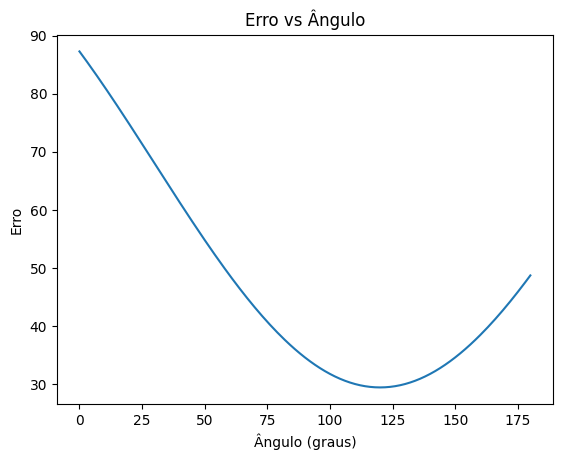

In [10]:
angle_est, angles, errors = estimate_angle(signals, fs, mic_positions)

print("\n=== RESULTADO FINAL ===")
print("Ângulo real:", theta_deg)
print("Ângulo estimado:", angle_est)

plt.figure()
plt.plot(angles, errors)
plt.xlabel("Ângulo (graus)")
plt.ylabel("Erro")
plt.title("Erro vs Ângulo")
plt.show()

In [11]:

test_angles = np.arange(0, 181, 1)

errors = []
estimates = []

for theta in test_angles:
    
    # simular
    signals = simulate(theta, signal, fs, mic_positions)

    # estimar (usa o teu algoritmo atual)
    angle_est, _, _ = estimate_angle(signals, fs, mic_positions)

    # erro
    error = abs(angle_est - theta)

    errors.append(error)
    estimates.append(angle_est)

    print(f"Real: {theta}° | Estimado: {angle_est:.2f}° | Erro: {error:.2f}°")

Real: 0° | Estimado: 0.00° | Erro: 0.00°
Real: 1° | Estimado: 0.00° | Erro: 1.00°
Real: 2° | Estimado: 0.00° | Erro: 2.00°
Real: 3° | Estimado: 11.00° | Erro: 8.00°
Real: 4° | Estimado: 11.00° | Erro: 7.00°
Real: 5° | Estimado: 11.00° | Erro: 6.00°
Real: 6° | Estimado: 11.00° | Erro: 5.00°
Real: 7° | Estimado: 11.00° | Erro: 4.00°
Real: 8° | Estimado: 11.00° | Erro: 3.00°
Real: 9° | Estimado: 11.00° | Erro: 2.00°
Real: 10° | Estimado: 11.00° | Erro: 1.00°
Real: 11° | Estimado: 11.00° | Erro: 0.00°
Real: 12° | Estimado: 11.00° | Erro: 1.00°
Real: 13° | Estimado: 11.00° | Erro: 2.00°
Real: 14° | Estimado: 11.00° | Erro: 3.00°
Real: 15° | Estimado: 21.00° | Erro: 6.00°
Real: 16° | Estimado: 21.00° | Erro: 5.00°
Real: 17° | Estimado: 21.00° | Erro: 4.00°
Real: 18° | Estimado: 21.00° | Erro: 3.00°
Real: 19° | Estimado: 21.00° | Erro: 2.00°
Real: 20° | Estimado: 21.00° | Erro: 1.00°
Real: 21° | Estimado: 21.00° | Erro: 0.00°
Real: 22° | Estimado: 21.00° | Erro: 1.00°
Real: 23° | Estimado: 21

## Alguns problemas atuais:

  - Sistema com poucos microfones tem resolução angular limitada
  - GCC-PHAT com sinais não-broadband gera quantização angular
  - Erros aparecem em “clusters” de ângulos
  - Precisão depende fortemente do conteúdo espectral do áudio
  - Geometria triangular não garante boa resolução uniforme em todos os ângulos

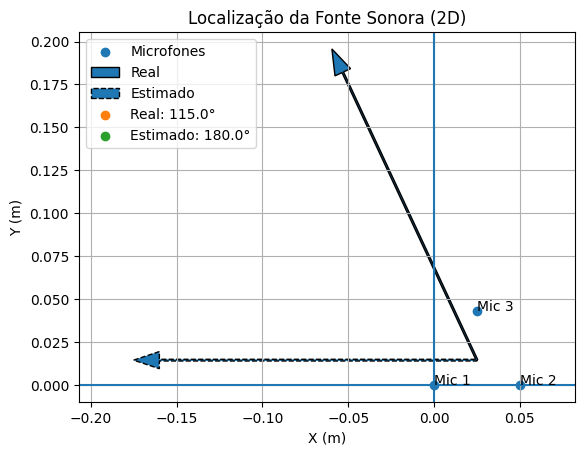

REAL VECTOR: [-0.08452365  0.18126156]
EST VECTOR: [-2.0000000e-01  2.4492936e-17]
ORIGIN: [0.025      0.01443333]
[0.98569857 0.         2.32343248]


In [18]:
import matplotlib.pyplot as plt
import numpy as np

def plot_localization(mic_positions, real_angle, estimated_angle):
    plt.figure()

    # centro do array (origem)
    origin = np.mean(mic_positions, axis=0)

    # desenhar microfones
    plt.scatter(mic_positions[:,0], mic_positions[:,1], label="Microfones")
    
    for i, pos in enumerate(mic_positions):
        plt.text(pos[0], pos[1], f"Mic {i+1}")

    # função para converter ângulo → vetor
    def angle_to_vector(theta_deg, length=0.2):
        theta = np.deg2rad(theta_deg)
        return np.array([np.cos(theta), np.sin(theta)]) * length

    # vetor real
    real_vec = angle_to_vector(real_angle)
    
    # vetor estimado
    est_vec = angle_to_vector(estimated_angle)

    # desenhar setas
    plt.arrow(origin[0], origin[1], real_vec[0], real_vec[1],
              head_width=0.01, length_includes_head=True, label="Real")
    
    plt.arrow(origin[0], origin[1], est_vec[0], est_vec[1],
              head_width=0.01, linestyle='--', length_includes_head=True, label="Estimado")

    # decoração
    plt.axhline(0)
    plt.axvline(0)
    plt.grid()
    plt.axis("equal")
    
    plt.title("Localização da Fonte Sonora (2D)")
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    
    # legenda manual (porque arrows não aparecem automaticamente)
    plt.scatter([], [], label=f"Real: {real_angle:.1f}°")
    plt.scatter([], [], label=f"Estimado: {estimated_angle:.1f}°")

    plt.legend()
    plt.show()
    
    print("REAL VECTOR:", real_vec)
    print("EST VECTOR:", est_vec)
    print("ORIGIN:", origin)
    print(delays_samples)
    
angle_est, _, _ = estimate_angle(signals, fs, mic_positions)

plot_localization(mic_positions, theta_deg, angle_est)


## ?Perceber porque é que dá esse estimado bastante diferente?